In [126]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
base_dir = "../datasets"

dataset_files = {
    "data": "data.csv",
    "data_changping": "PRSA_Data_Changping_20130301-20170228.csv",
    "data_dingling": "PRSA_Data_Dingling_20130301-20170228.csv",
    "data_dongsi": "PRSA_Data_Dongsi_20130301-20170228.csv",
    "data_guanyuan": "PRSA_Data_Guanyuan_20130301-20170228.csv",
    "data_gucheng": "PRSA_Data_Gucheng_20130301-20170228.csv",
    "data_huairou": "PRSA_Data_Huairou_20130301-20170228.csv",
    "data_nongzhanguan": "PRSA_Data_Nongzhanguan_20130301-20170228.csv",
    "data_shunyi": "PRSA_Data_Shunyi_20130301-20170228.csv",
    "data_tiantan": "PRSA_Data_Tiantan_20130301-20170228.csv",
    "data_wanliu": "PRSA_Data_Wanliu_20130301-20170228.csv",
    "data_wanshouxigong": "PRSA_Data_Wanshouxigong_20130301-20170228.csv",
    "test": "test.csv",
}

# Dataframe populated with all datasets
dfs = {
    name: pd.read_csv(os.path.join(base_dir, filename))
    for name, filename in dataset_files.items()
}

Basic comparison of dataset features

In [128]:
df_columns = {name: list(df.columns) for name, df in dfs.items()}

baseline_name = "data_changping"
baseline_cols = df_columns[baseline_name]

print(f"Baseline dataset: '{baseline_name}' ({len(baseline_cols)} columns)")
print('\tColumns:',df_columns[baseline_name])
print("-" * 60)

all_match = True
for name, cols in df_columns.items():
    if name == baseline_name:
        continue

    if cols == baseline_cols:
        print(f"✅ {name:<20} : Perfect match.")
    else:
        all_match = False
        print(f"❌ {name:<20} : MISMATCH found!")
        print('\tColumns:',cols)

Baseline dataset: 'data_changping' (18 columns)
	Columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']
------------------------------------------------------------
❌ data                 : MISMATCH found!
	Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
✅ data_dingling        : Perfect match.
✅ data_dongsi          : Perfect match.
✅ data_guanyuan        : Perfect match.
✅ data_gucheng         : Perfect match.
✅ data_huairou         : Perfect match.
✅ data_nongzhanguan    : Perfect match.
✅ data_shunyi          : Perfect match.
✅ data_tiantan         : Perfect match.
✅ data_wanliu          : Perfect match.
✅ data_wanshouxigong   : Perfect match.
❌ test                 : MISMATCH found!
	Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [129]:
# Location datasets
location_dfs = {
    name: df
    for name, df in dfs.items()
    if name not in ["data", "test"]
}

# Other datasets
data_csv = dfs['data']
test_csv = dfs['test']

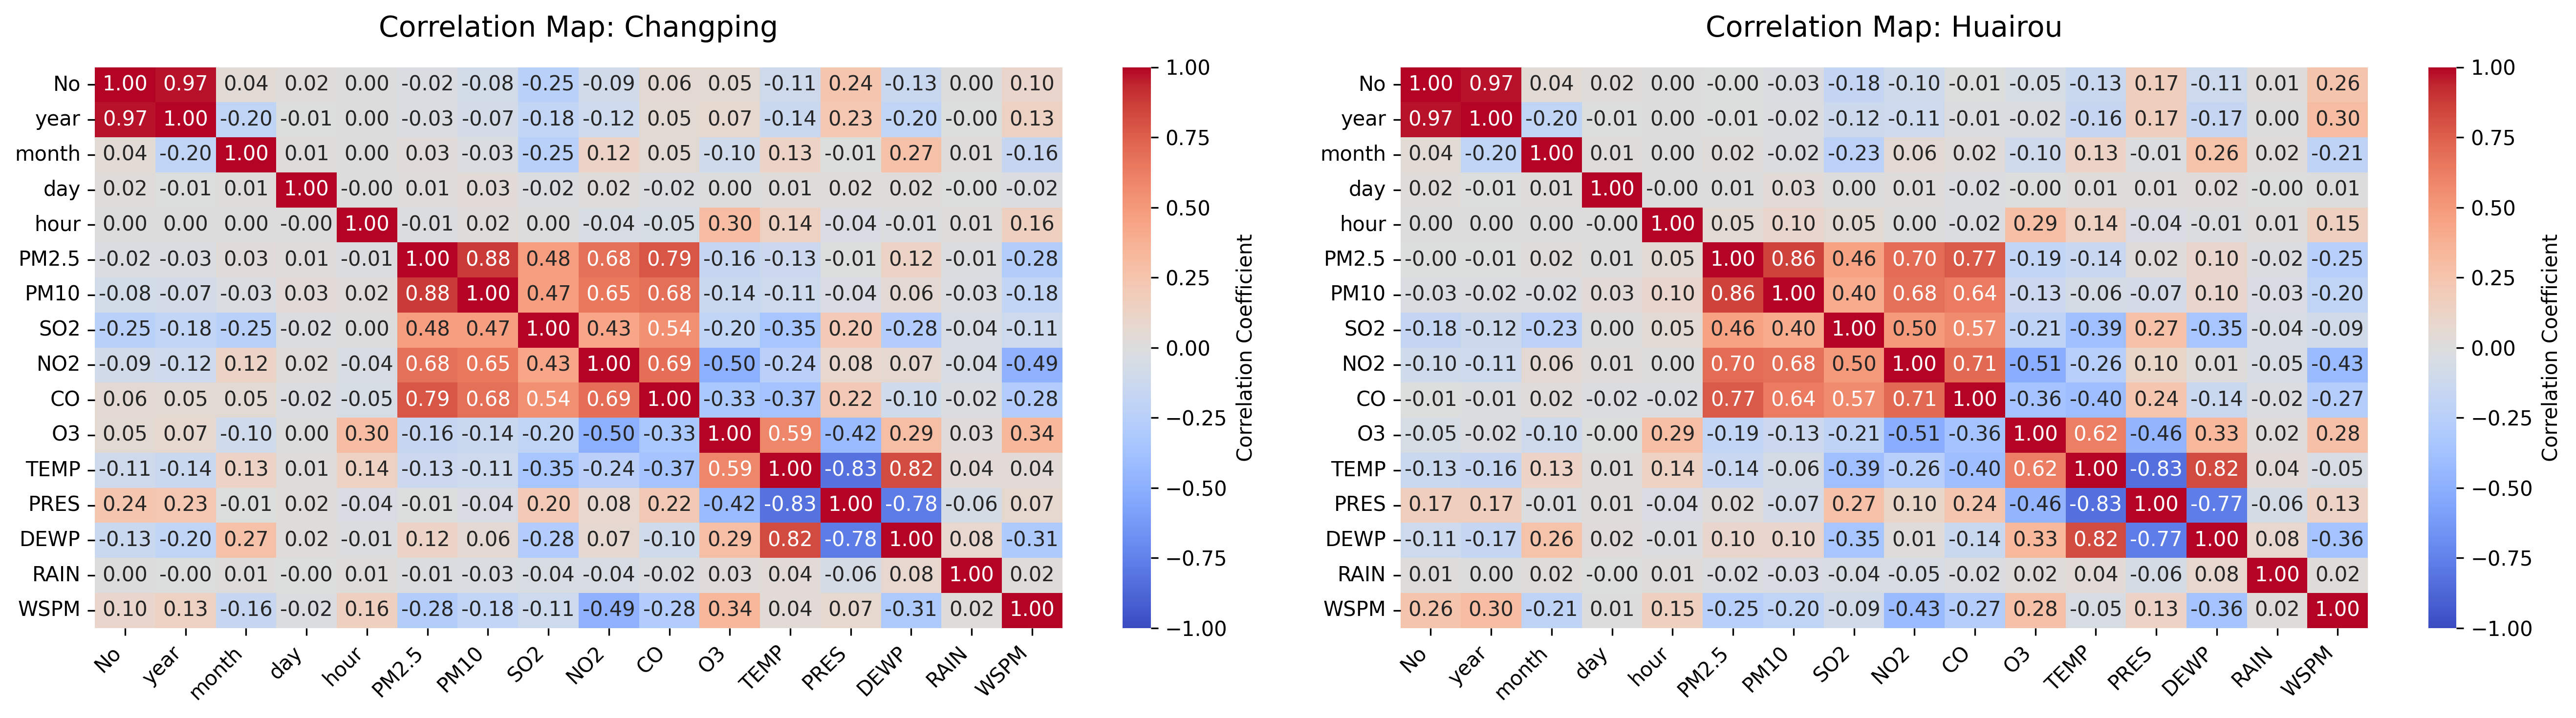

In [130]:
# Correlation matrix for each location
corr_maps = {
    name: df.corr(numeric_only=True) for name, df in location_dfs.items()
}

fig1, axes = plt.subplots(1, 2, figsize=(18, 5))
plt.rcParams["figure.dpi"] = 150

# Heatmap for Changping
sns.heatmap(
    corr_maps["data_changping"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[0],
    cbar_kws={"label": "Correlation Coefficient"},
)
axes[0].set_title("Correlation Map: Changping", fontsize=14, pad=15)
axes[0].set_xticklabels(
    axes[0].get_xticklabels(), rotation=45, ha="right"
)  

# Heatmap for Huairou
sns.heatmap(
    corr_maps["data_huairou"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[1],
    cbar_kws={"label": "Correlation Coefficient"},
)
axes[1].set_title("Correlation Map: Huairou", fontsize=14, pad=15)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()

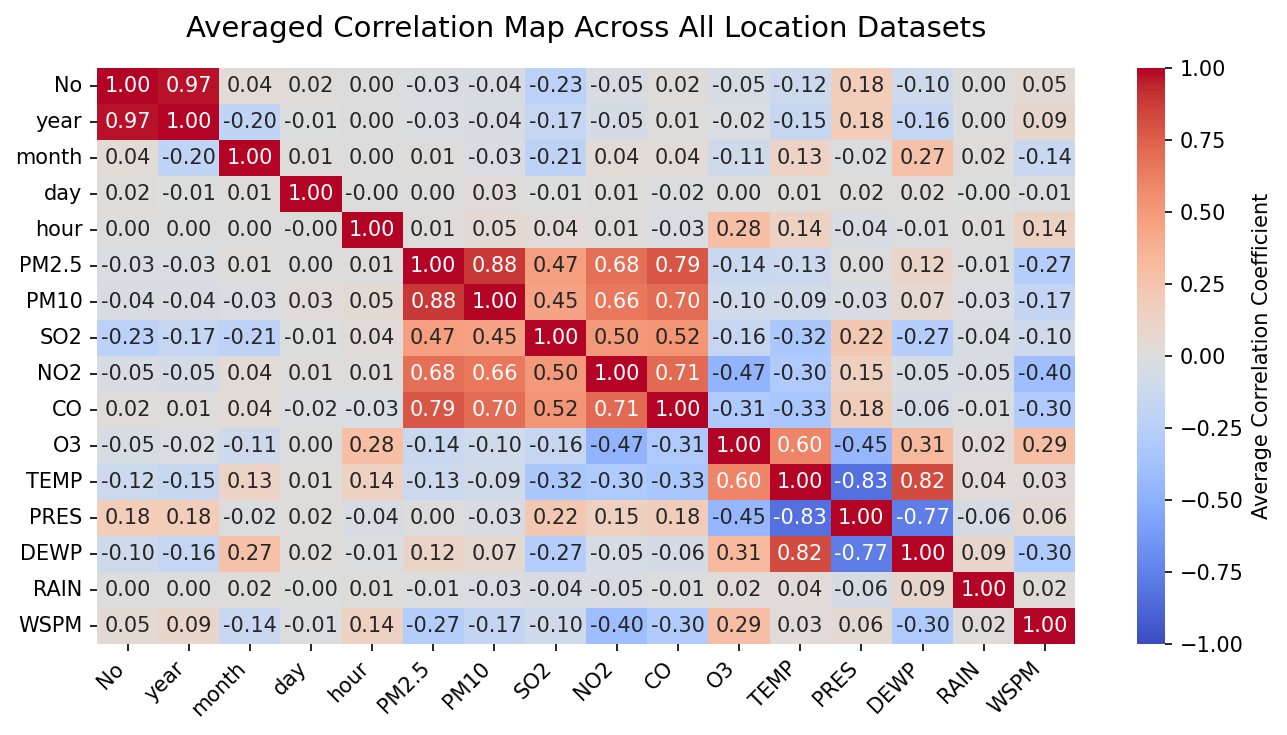

In [131]:
avg_corr = sum(corr_maps.values()) / len(corr_maps)

fig, ax = plt.subplots(1, 1, figsize=(9, 5))

sns.heatmap(
    avg_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=ax,
    cbar_kws={"label": "Average Correlation Coefficient"},
)

ax.set_title(
    "Averaged Correlation Map Across All Location Datasets",
    fontsize=14,
    pad=15,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()